# Laboration 3: Optimising a Catalytic Reaction

**Team name:**
**Members:**
**Date:**

Follow `instruction.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Before you start: open `plant_client.py` and fill in `SERVER_URL`,
`TEAM`, and `TOKEN` (given to you by your instructor).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pyDOE3
from scipy.stats import qmc, t as t_dist
from scipy import stats
from scipy.optimize import minimize

from plant_client import run_experiment, leaderboard

RANDOM_STATE = 42

# Keep every experiment you run here -- you'll need the full history in
# Step 3, not just your latest batch.
history = pd.DataFrame(columns=["T", "c", "rpm", "rate"])

def log(result):
    """Append a run_experiment() result to the running history table."""
    global history
    history = pd.concat([history, result], ignore_index=True)
    return history


# Setup for Colab: download plant_client.py and fill in the server address,
# team name and token, so `from plant_client import ...` below works.
import importlib, re, sys, urllib.request

---
## Step 1 — Factorial Screening (0:00–0:45)

Three candidate factors this time: **c**, **T**, and **stirring rate
(rpm)** — nobody has confirmed rpm actually matters, that's what this
step is for.

- [ ] Design a 2³ factorial (8 corner points) around the OVAT point (c=2.0, T=25.0) and a sensible centre rpm, plus a few centre-point replicates
- [ ] Run it via `run_experiment`
- [ ] Code each factor to +/-1 (e.g. `c_coded = (c - 2.0) / 0.5`) before fitting -- see the TODO below for why this matters
- [ ] Fit `rate ~ c_coded * T_coded * rpm_coded` on the corner points — which effects are significant? (→ **Checkpoint 1a**)
- [ ] If rpm (and its interactions) aren't significant, drop it and fix it at a convenient value from here on
- [ ] Compare centre-point average to corner-point average — is there curvature? (→ **Checkpoint 1b**)

In [59]:
import numpy as np

# TODO:
# 1. choose your factor ranges (e.g. c +/- 0.5 mM, T +/- 5 degC around
# the OVAT point, rpm +/- 200 around a centre value like 500)
# 2. build the 8 corner points (save in a df)
# 3. Build a few centre-point repeats (save in a separate df)

# HINT: itertools.product(levels_c, levels_T, levels_rpm)
# is the easiest way to build the 2^3 corners.
n_reps = 2   # two replicates per design point
design_3 = pyDOE3.ff2n(3)
df_design = pd.DataFrame(design_3, columns=['T', 'c', 'rpm'])
df_coded = df_design
print(df_coded)
# Add natural units
df_design['T'] = 25 + 5*df_design['T']
df_design['c'] = 2   +   0.5*df_design['c']
df_design['rpm'] = 500 + 200*df_design['rpm']

dfcenter = pd.DataFrame([(0,0,0)] * 3, columns=['T', 'c', 'rpm'])
center_val = pd.DataFrame([(25.0, 2.0, 500.0)]*3 , columns=['T', 'c', 'rpm'])
print(dfcenter)
print(center_val)



     T    c  rpm
0 -1.0 -1.0 -1.0
1 -1.0 -1.0  1.0
2 -1.0  1.0 -1.0
3 -1.0  1.0  1.0
4  1.0 -1.0 -1.0
5  1.0 -1.0  1.0
6  1.0  1.0 -1.0
7  1.0  1.0  1.0
   T  c  rpm
0  0  0    0
1  0  0    0
2  0  0    0
      T    c    rpm
0  25.0  2.0  500.0
1  25.0  2.0  500.0
2  25.0  2.0  500.0


In [64]:
# TODO:
# 1. run the design with result = run_experiment(name="...", T=..., c=..., rpm=...).
# You will have to run the corner points and centre-points
# separately (it is needed for the next parts of the lab)
# 2. Use log(result) to add it to `history`.

# TIP: the run_experiment function is defined in plant_client.py.

corner_list = []
center_list = []

print("Running and logging corner point experiments...")
for i, row in df_design.iterrows():
    # Wrap the scalar values in lists as run_experiment expects iterable inputs
    result = run_experiment(name=f"corner_point_{i+1}", T=[row['T']], c=[row['c']], rpm=[row['rpm']])
    log(result)
    corner_list.append(result)

for i, row in center_val.iterrows():
    # Wrap the scalar values in lists as run_experiment expects iterable inputs
    result = run_experiment(name=f"center_point_{i+1}", T=[row['T']], c=[row['c']], rpm=[row['rpm']])
    log(result)
    center_list.append(result)



Running and logging corner point experiments...
'corner_point_1': loaded 1 cached run(s), no new experiments.
'corner_point_2': loaded 1 cached run(s), no new experiments.
'corner_point_3': loaded 1 cached run(s), no new experiments.
'corner_point_4': loaded 1 cached run(s), no new experiments.
'corner_point_5': loaded 1 cached run(s), no new experiments.
'corner_point_6': loaded 1 cached run(s), no new experiments.
'corner_point_7': loaded 1 cached run(s), no new experiments.
'corner_point_8': loaded 1 cached run(s), no new experiments.
'center_point_1': loaded 1 cached run(s), no new experiments.
'center_point_2': loaded 1 cached run(s), no new experiments.
'center_point_3': loaded 1 cached run(s), no new experiments.


,T,c,rpm,rate
0,20.0,1.5,300.0,3.3070
1,20.0,1.5,700.0,3.7163
2,20.0,2.5,300.0,4.8697
3,20.0,2.5,700.0,4.9749
4,30.0,1.5,300.0,6.1755
5,30.0,1.5,700.0,6.2369
6,30.0,2.5,300.0,7.6200
7,30.0,2.5,700.0,7.7419
8,25.0,2.0,500.0,5.7902
9,25.0,2.0,500.0,5.6975


In [70]:

# TODO:
# 1. For the result, code each factor to +/-1 using the factorial's own half-ranges
# (e.g. c_coded = (c - 2.0) / 0.5) and add these as new columns.
# 2. THEN fit rate ~ c_coded * T_coded * rpm_coded (statsmodels.formula.api.ols)
# ONLY on the corner points. (Fitting on raw units (mM, degC, rpm) instead will give
# you a badly ill-conditioned model where every effect looks non-significant
# that's a red flag to code your variables, not a real finding.)

# TIP: .summary() shows you the coefficients, signs, and p-values for every
# main effect and interaction.
# Define center points and half-ranges for coding

df_model_data = pd.concat(corner_list + center_list, ignore_index=True)
# Code each factor to +/-1
df_model_data['c_coded'] = (df_model_data['c'] - 2) /0.5
df_model_data['T_coded'] = (df_model_data['T'] - 25) /5
df_model_data['rpm_coded'] = (df_model_data['rpm'] - 500) /200

display(df_model_data[['c_coded', 'T_coded', 'rpm_coded', 'rate']])

# Fit rate ~ c_coded * T_coded * rpm_coded (statsmodels.formula.api.ols)
# ONLY on the corner points (df_model_data currently contains only corner points based on previous steps).
model = smf.ols(
    'rate ~ c_coded * T_coded * rpm_coded',
    data=df_model_data
).fit()

# Print the model summary
print("\nOLS Model Summary:")
print(model.summary())


,c_coded,T_coded,rpm_coded,rate
0,-1.0,-1.0,-1.0,3.3070
1,-1.0,-1.0,1.0,3.7163
2,1.0,-1.0,-1.0,4.8697
3,1.0,-1.0,1.0,4.9749
4,-1.0,1.0,-1.0,6.1755
5,-1.0,1.0,1.0,6.2369
6,1.0,1.0,-1.0,7.6200
7,1.0,1.0,1.0,7.7419
8,0.0,0.0,0.0,5.7902
9,0.0,0.0,0.0,5.6975



OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     172.4
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           0.000668
Time:                        15:12:20   Log-Likelihood:                 14.332
No. Observations:                  11   AIC:                            -12.66
Df Residuals:                       3   BIC:                            -9.481
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

Baserat på analysen av OLS-rapporten, om `rpm` och dess interaktioner bedöms vara statistiskt obetydliga (dvs. p-värdena är höga), kan vi förenkla modellen genom att ta bort `rpm` som en variabel.

När du har tagit bort `rpm` som en rörlig variabel från din modell kommer du att använda ett **fast `rpm`-värde** för alla framtida experiment. Detta värde väljs oftast som mittpunkten (t.ex. 500 rpm) från ditt ursprungliga designområde.

In [71]:
# TODO: decide whether to drop rpm based on the model above. If you do,
# note it here (and on the answer sheet, Checkpoint 1a) and pick a fixed      we drop the rpm based
# rpm value to use for the rest of the lab.

fixed_rpm_value = 500.0
print(corner_list)


[      T    c    rpm   rate
0  20.0  1.5  300.0  3.307,       T    c    rpm    rate
0  20.0  1.5  700.0  3.7163,       T    c    rpm    rate
0  20.0  2.5  300.0  4.8697,       T    c    rpm    rate
0  20.0  2.5  700.0  4.9749,       T    c    rpm    rate
0  30.0  1.5  300.0  6.1755,       T    c    rpm    rate
0  30.0  1.5  700.0  6.2369,       T    c    rpm  rate
0  30.0  2.5  300.0  7.62,       T    c    rpm    rate
0  30.0  2.5  700.0  7.7419]


In [72]:
# TODO: compare the centre-point average rate to the average of the 8
# corner points. A meaningfully different value suggests curvature.
# Reason about this on the answer sheet (Checkpoint 1b), not just here.

# Slå samman listorna av DataFrames till faktiska DataFrames
df_corners = pd.concat(corner_list, ignore_index=True)
df_centers = pd.concat(center_list, ignore_index=True)

# Nu kan vi enkelt beräkna medelvärdet av kolumnen 'rate'
average_corner_rate = df_corners['rate'].mean()
average_center_rate = df_centers['rate'].mean()

print(f"\nAverage rate for corner points (with fixed rpm): {average_corner_rate:.4f} mol/s")
print(f"Average rate for center points (with fixed rpm): {average_center_rate:.4f} mol/s")

# Jämförelse för att indikera krökning (curvature)
difference = abs(average_center_rate - average_corner_rate)
print(f"Absolut skillnad: {difference:.4f} mol/s")


Average rate for corner points (with fixed rpm): 5.5803 mol/s
Average rate for center points (with fixed rpm): 5.7076 mol/s
Absolut skillnad: 0.1274 mol/s


---
## Step 2 — Steepest Ascent (0:45–1:30)

- [ ] Use the significant main effects from Step 1 (c and T, assuming rpm was dropped) to compute an ascent direction
- [ ] Run a sequence of points stepping along that direction, until the rate stops improving. If you fixed the repm value, keep it fixed at your chosen value.
- [ ] Keep `log()`-ing every result so `history` stays complete

In [74]:
# TODO:
# 1. Compute the steepest-ascent direction from your Step 1 model's c
# and T coefficients (the ratio of the fitted effects gives the relative
# step sizes)
# 2. Choose a step size and take your first step. If you fixed
# your rpm value, pass it on every call.

b1, b2 = model.params['T_coded'], model.params['c_coded']
print(f'First-order coefficients: b1 = {b1:.3f}, b2 = {b2:.3f}')
print(f'Steepest ascent direction: ({b1:.3f}, {b2:.3f})')
#step size
step_T_coded = 0.2

#step size in coded
step_c_coded = step_T_coded * (b2 / b1)

# steps in natural units
step_T = step_T_coded * 5
step_c = step_c_coded * 0.5

print(f"Stegstorlek i fysikaliska enheter:")
print(f"  Delta T: +{step_T:.2f} °C per steg")
print(f"  Delta c: +{step_c:.3f} mM per steg\n")

target_T = 25 + step_T
target_c = 2 + step_c

result = run_experiment(
        name=f"steepest_ascent_stepping_",
        T=[target_T],
        c=[target_c],
        rpm=[fixed_rpm_value]
    )
log(result)
display(history)





First-order coefficients: b1 = 1.363, b2 = 0.721
Steepest ascent direction: (1.363, 0.721)
Stegstorlek i fysikaliska enheter:
  Delta T: +1.00 °C per steg
  Delta c: +0.053 mM per steg

Team 'Labgrp17': 1 experiment(s) this call, 107 total so far.


,T,c,rpm,rate,point_set,name,Tsq,csq
0,20.0,1.500000,300.0,3.3070,NaN,corner_point_1,400.0,2.25
1,20.0,1.500000,700.0,3.7163,NaN,corner_point_2,400.0,2.25
2,20.0,2.500000,300.0,4.8697,NaN,corner_point_3,400.0,6.25
3,20.0,2.500000,700.0,4.9749,NaN,corner_point_4,400.0,6.25
4,30.0,1.500000,300.0,6.1755,NaN,corner_point_5,900.0,2.25
...,...,...,...,...,...,...,...,...
97,30.0,2.500000,700.0,7.7419,NaN,NaN,NaN,NaN
98,25.0,2.000000,500.0,5.7902,NaN,NaN,NaN,NaN
99,25.0,2.000000,500.0,5.6975,NaN,NaN,NaN,NaN
100,25.0,2.000000,500.0,5.6352,NaN,NaN,NaN,NaN


In [16]:

# TODO:
# Perform a steepest ascent along the ascent direction, starting from the OVAT point.
# Run the experiments using result = run_experiment(name, T, c, rpm)
# and log each result using log(result).
# Print the best (T, c, rate) you've found so far after each step.
# Continue the steepest ascent until the rate stops improving, using a reasonable criteria.

# Start from the center point
x_start = np.array([0.0, 0.0])
step_vector_coded = (0.5 / abs(b1)) * np.array([b1, b2])

# Find the baseline center point rate as the starting comparison rate
last_step_rate = history[history['point_set'] == 'curvature_center']['rate'].mean()
if pd.isna(last_step_rate):
    last_step_rate = 5.6796

print(f"Baseline center point rate: {last_step_rate:.4f} mol/s\n")

max_steps = 10

def get_existing_experiment_rate(experiment_name):
    """Checks if an experiment with the given name exists in history and returns its rate."""
    matching_experiments = history[history['name'] == experiment_name]
    if not matching_experiments.empty:
        return matching_experiments['rate'].iloc[0]
    return None

print("--- Steepest Ascent ---")
for s in range(1, max_steps + 1):
    current_coded = x_start + s * step_vector_coded
    target_T = 25 + current_coded[0] * 5
    target_c = 2 + current_coded[1] * 0.5

    experiment_name = f"steepest_ascent_stepnumber_{s}"

    print(f"\n--- Testar steg {s} ---")
    print(f"Settings: T = {target_T:.2f} °C, c = {target_c:.3f} mM (rpm = {fixed_rpm_value}) ({experiment_name})")

    existing_rate = get_existing_experiment_rate(experiment_name)

    if existing_rate is not None:
        current_rate = existing_rate
        print(f"Experiment '{experiment_name}' already logged. Rate = {current_rate:.4f} mol/s")
    else:
        # Run the experiment if it is not found in history
        result = run_experiment(
            name=experiment_name,
            T=[target_T],
            c=[target_c],
            rpm=[fixed_rpm_value]
        )
        result['name'] = experiment_name
        log(result)
        current_rate = result['rate'].iloc[0]
        print(f"Resultat: Rate = {current_rate:.4f} mol/s")

    # Comparing the current step's rate to the rate of the last step
    if current_rate > last_step_rate:
        print(f"Improvement! Current ({current_rate:.4f}) is better than previous ({last_step_rate:.4f})")
        # Update reference for next iteration comparison
        last_step_rate = current_rate
    else:
        print(f"\nStopping steepest ascent immediately because rate stagnated or decreased. Current ({current_rate:.4f}) <= Previous ({last_step_rate:.4f})")
        break

print("\n--- Steepest Ascent Completed ---")
display(history.tail(15))

Current aligned history columns: ['T', 'c', 'rpm', 'rate', 'point_set', 'name']
Baseline center point rate: 5.8117 mol/s

--- Steepest Ascent ---

--- Testar steg 1 ---
Settings: T = 27.50 °C, c = 2.134 mM (rpm = 500.0) (steepest_ascent_stepnumber_1)
Team 'Labgrp17': 1 experiment(s) this call, 75 total so far.
Resultat: Rate = 6.5006 mol/s
Improvement! Current (6.5006) is better than previous (5.8117)

--- Testar steg 2 ---
Settings: T = 30.00 °C, c = 2.268 mM (rpm = 500.0) (steepest_ascent_stepnumber_2)
Team 'Labgrp17': 1 experiment(s) this call, 76 total so far.
Resultat: Rate = 7.2300 mol/s
Improvement! Current (7.2300) is better than previous (6.5006)

--- Testar steg 3 ---
Settings: T = 32.50 °C, c = 2.403 mM (rpm = 500.0) (steepest_ascent_stepnumber_3)
Team 'Labgrp17': 1 experiment(s) this call, 77 total so far.
Resultat: Rate = 7.9136 mol/s
Improvement! Current (7.9136) is better than previous (7.2300)

--- Testar steg 4 ---
Settings: T = 35.00 °C, c = 2.537 mM (rpm = 500.0) (st

,T,c,rpm,rate,point_set,name
14,30.0,2.500000,500.0,7.3687,curvature_corner,curvature_corner
15,30.0,2.500000,500.0,7.8960,curvature_corner,curvature_corner
16,25.0,2.000000,500.0,5.9206,curvature_center,curvature_center
17,25.0,2.000000,500.0,5.6395,curvature_center,curvature_center
18,25.0,2.000000,500.0,5.8750,curvature_center,curvature_center
19,26.0,2.053681,500.0,6.1835,steepest_ascent,steepest_ascent
20,27.5,2.134202,500.0,6.5006,steepest_ascent,steepest_ascent_stepnumber_1
21,30.0,2.268404,500.0,7.2300,steepest_ascent,steepest_ascent_stepnumber_2
22,32.5,2.402606,500.0,7.9136,steepest_ascent,steepest_ascent_stepnumber_3
23,35.0,2.536807,500.0,8.3854,steepest_ascent,steepest_ascent_stepnumber_4


---
## Step 3 — Response Surface Optimisation (1:30–3:00)

- [ ] Design a Latin-hypercube set of points around the best region found in Step 2 (`scipy.stats.qmc.LatinHypercube`), rpm still fixed
- [ ] Run it, fit a quadratic model (`rate ~ c + T + I(c**2) + I(T**2) + c:T`)
- [ ] Contour plot of predicted rate, with your best point and the model's predicted optimum marked (→ **Checkpoint 3b**)
- [ ] Confirm the predicted optimum with 1-2 extra experiments (an informal first check -- Step 4 makes this rigorous)

In [33]:
# TODO: use qmc.LatinHypercube(d=2, seed=RANDOM_STATE) to generate sample
# points in [0,1]^2 for (c, T), then scale them to your chosen region.
# qmc.scale(sample, l_bounds, u_bounds) does the scaling for you. If you
# fixed your rpm value, rpm stays fixed at your chosen value for every point.
sample = qmc.LatinHypercube(d=2, seed=RANDOM_STATE)
points = sample.random(n=10)
bounds  = [(42.5, 47.5), (2.939413, 3.207817)]
lo = np.array([b[0] for b in bounds])
hi = np.array([b[1] for b in bounds])
scale_points = qmc.scale(points, lo, hi)


(10, 2)


In [34]:
# TODO:
# 1. run the LHS design and log() the results.
# 2. Fit the quadratic model on the FULL history (df_full = history) or
# just the RSM-region points: your call, but say which on the answer sheet.

print("--- Startar LHS-experiment ---")
for i in range(len(scale_points)):
    target_c = scale_points[i, 1]
    target_T = scale_points[i, 0]
    experiment_name = f"LHS_design_{i+1}"

    # Run the experiment with fixed RPM
    result = run_experiment(
        name=experiment_name,
        T=[target_T],
        c=[target_c],
        rpm=[fixed_rpm_value]
    )

    log(result)
    print(f"LHS Experiment {i+1}: T={target_T:.2f} °C, c={target_c:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

--- Startar LHS-experiment ---
Team 'Labgrp17': 1 experiment(s) this call, 84 total so far.
LHS Experiment 1: T=43.61 °C, c=3.116 mM -> Rate=9.4193 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 85 total so far.
LHS Experiment 2: T=47.07 °C, c=3.028 mM -> Rate=9.5316 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 86 total so far.
LHS Experiment 3: T=42.95 °C, c=3.155 mM -> Rate=9.3778 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 87 total so far.
LHS Experiment 4: T=46.62 °C, c=2.999 mM -> Rate=9.4274 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 88 total so far.
LHS Experiment 5: T=44.94 °C, c=3.196 mM -> Rate=9.5067 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 89 total so far.
LHS Experiment 6: T=43.31 °C, c=3.076 mM -> Rate=9.5311 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 90 total so far.
LHS Experiment 7: T=45.68 °C, c=2.971 mM -> Rate=9.2541 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 91 total so far.
LHS Experiment 8: T=46.28 °C, c=3.148 mM -> Rat

,T,c,rpm,rate,point_set,name
27,45.000000,3.073615,500.0,9.8103,steepest_ascent,steepest_ascent_stepnumber_8
28,47.500000,3.207817,500.0,9.6051,steepest_ascent,steepest_ascent_stepnumber_9
29,43.613022,3.115516,500.0,9.4193,NaN,NaN
30,47.070701,3.028057,500.0,9.5316,NaN,NaN
31,42.952911,3.154791,500.0,9.3778,NaN,NaN
32,46.619430,2.998836,500.0,9.4274,NaN,NaN
33,44.935943,3.195728,500.0,9.5067,NaN,NaN
34,43.314601,3.075581,500.0,9.5311,NaN,NaN
35,45.678067,2.971011,500.0,9.2541,NaN,NaN
36,46.278293,3.148037,500.0,9.5004,NaN,NaN


In [36]:
df_full = history
quad_model = smf.ols(
    'rate ~ c + T + I(c**2) + I(T**2) + c:T',
    data=df_full
).fit()
print(quad_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1741.
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           5.89e-39
Time:                        11:32:38   Log-Likelihood:                 25.465
No. Observations:                  39   AIC:                            -38.93
Df Residuals:                      33   BIC:                            -28.95
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.3329      0.533    -17.499      0.0

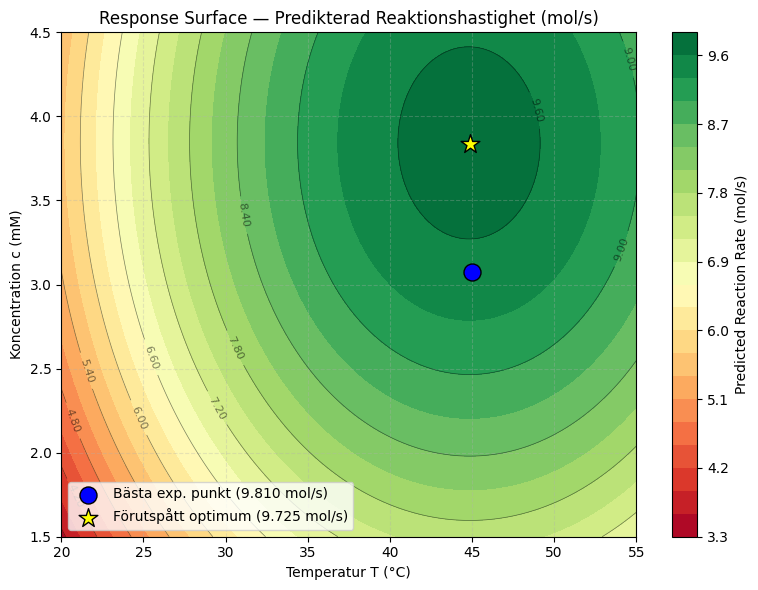

Modellens predikterade optimum på gridden:
  T = 44.90 °C
  c = 3.836 mM
  Predikterad Rate = 9.7247 mol/s

Bästa körda experimentet i historiken:
  T = 45.00 °C
  c = 3.074 mM
  Uppmätt Rate = 9.8103 mol/s


In [41]:
# TODO:
# 1. Build a grid over your explored (c, T) region. You will need
# to decide on the factor ranges, and the number of grid points.
# 2. Predict the rate with your fitted model at every grid point.
# 3. Make a contour plot using plt.contourf / ax.contour.
# Mark your best experimental point and the model's predicted optimum
# (e.g. from scipy.optimize.minimize on the negative of
# your fitted model, or just the grid's argmax).

# 1. Build a grid over your explored (T, c) region.
# Based on history, T spans ~20 to 48 °C, c spans ~1.5 to 3.2 mM
T_grid = np.linspace(20.0, 55.0, 150)
c_grid = np.linspace(1.5, 4.5, 150)

T_mesh, c_mesh = np.meshgrid(T_grid, c_grid)

# 2. Predict the rate with your fitted model (quad_model) at every grid point
pred_df = pd.DataFrame({
    'T': T_mesh.ravel(),
    'c': c_mesh.ravel()
})

Z = quad_model.predict(pred_df).values.reshape(T_mesh.shape)

# Find the model's predicted optimum on this grid
opt_idx = np.unravel_index(Z.argmax(), Z.shape)
T_opt_pred = T_mesh[opt_idx]
c_opt_pred = c_mesh[opt_idx]
rate_opt_pred = Z[opt_idx]

# Find the best actual experimental point from history
best_exp_idx = history['rate'].idxmax()
best_exp = history.loc[best_exp_idx]
T_best_exp = best_exp['T']
c_best_exp = best_exp['c']
rate_best_exp = best_exp['rate']

# 3. Make a contour plot
plt.figure(figsize=(8, 6))
cf = plt.contourf(T_mesh, c_mesh, Z, levels=20, cmap='RdYlGn')
plt.colorbar(cf, label='Predicted Reaction Rate (mol/s)')

# Add contour lines for readability
lines = plt.contour(T_mesh, c_mesh, Z, levels=10, colors='black', linewidths=0.5, alpha=0.5)
plt.clabel(lines, inline=True, fontsize=8, fmt='%.2f')

# Mark best experimental point
plt.scatter(T_best_exp, c_best_exp, s=150, c='blue', marker='o', edgecolors='black',
            label=f"Bästa exp. punkt ({rate_best_exp:.3f} mol/s)", zorder=5)

# Mark predicted optimum
plt.scatter(T_opt_pred, c_opt_pred, s=200, c='yellow', marker='*', edgecolors='black',
            label=f"Förutspått optimum ({rate_opt_pred:.3f} mol/s)", zorder=5)

plt.xlabel('Temperatur T (°C)')
plt.ylabel('Koncentration c (mM)')
plt.title('Response Surface — Predikterad Reaktionshastighet (mol/s)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Modellens predikterade optimum på gridden:")
print(f"  T = {T_opt_pred:.2f} °C")
print(f"  c = {c_opt_pred:.3f} mM")
print(f"  Predikterad Rate = {rate_opt_pred:.4f} mol/s\n")

print(f"Bästa körda experimentet i historiken:")
print(f"  T = {T_best_exp:.2f} °C")
print(f"  c = {c_best_exp:.3f} mM")
print(f"  Uppmätt Rate = {rate_best_exp:.4f} mol/s")

In [43]:
# TODO:
# 1. Store the predicted optimum (c_star, T_star, rate_star)
# -- you'll reuse it in Step 4.
# 2. Run 1-2 confirmation experiments at (or near) your predicted optimum
# and compare the observed rate to the model's prediction.
c_star, T_star, rate_star = c_opt_pred, T_opt_pred, rate_opt_pred

result = run_experiment(
        name=f'Predicted_Optimum1',
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

log(result)
result = run_experiment(
        name=f'Predicted_Optimum2',
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

log(result)
print(f"Predicted Optimum: T={T_star:.2f} °C, c={c_star:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

Team 'Labgrp17': 1 experiment(s) this call, 94 total so far.
Team 'Labgrp17': 1 experiment(s) this call, 95 total so far.
Predicted Optimum: T=44.90 °C, c=3.836 mM -> Rate=9.7298 mol/s


,T,c,rpm,rate,point_set,name,Tsq,csq
29,43.613022,3.115516,500.0,9.4193,NaN,NaN,1902.095686,9.706441
30,47.070701,3.028057,500.0,9.5316,NaN,NaN,2215.650896,9.169129
31,42.952911,3.154791,500.0,9.3778,NaN,NaN,1844.952591,9.952703
32,46.619430,2.998836,500.0,9.4274,NaN,NaN,2173.371267,8.993017
33,44.935943,3.195728,500.0,9.5067,NaN,NaN,2019.238990,10.212680
34,43.314601,3.075581,500.0,9.5311,NaN,NaN,1876.154659,9.459196
35,45.678067,2.971011,500.0,9.2541,NaN,NaN,2086.485845,8.826904
36,46.278293,3.148037,500.0,9.5004,NaN,NaN,2141.680394,9.910137
37,44.222708,3.071902,500.0,9.6574,NaN,NaN,1955.647868,9.436583
38,45.086184,2.949299,500.0,9.4112,NaN,NaN,2032.764025,8.698366


---
## Step 4 — How Sure Are You? A Confidence Interval (3:00–3:45)

- [ ] Run 8-10 replicate experiments at your predicted optimum (same T*, c*, and rpm every time).
- [ ] Compute the sample mean and standard deviation of the resulting rates
- [ ] Build a 95% confidence interval on the true mean rate there (→ **Checkpoint 4a**)
- [ ] Check whether the OVAT baseline (5.77 mol/s) and your model's predicted rate (Checkpoint 3b) fall inside or outside your CI
- [ ] Reflect on the sample-size / CI-width trade-off (→ **Checkpoint 4b**)

In [44]:
# TODO: run 8-10 replicate experiments at (c_star, T_star), same settings
# every call. log() the results.
for i in range(8):
    experiment_name = f"Predicted_Optimum_replicate{i+1}"

    # Run the experiment with fixed RPM
    result = run_experiment(
        name=experiment_name,
        T=[T_star],
        c=[c_star],
        rpm=[fixed_rpm_value]
    )

    log(result)
    print(f"Predicted_Optimum_replicate{i+1}: T={T_star:.2f} °C, c={c_star:.3f} mM -> Rate={result['rate'].iloc[0]:.4f} mol/s")

display(history.tail(12))

Team 'Labgrp17': 1 experiment(s) this call, 96 total so far.
Predicted_Optimum_replicate1: T=44.90 °C, c=3.836 mM -> Rate=9.7866 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 97 total so far.
Predicted_Optimum_replicate2: T=44.90 °C, c=3.836 mM -> Rate=9.5901 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 98 total so far.
Predicted_Optimum_replicate3: T=44.90 °C, c=3.836 mM -> Rate=9.7144 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 99 total so far.
Predicted_Optimum_replicate4: T=44.90 °C, c=3.836 mM -> Rate=9.8095 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 100 total so far.
Predicted_Optimum_replicate5: T=44.90 °C, c=3.836 mM -> Rate=9.5959 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 101 total so far.
Predicted_Optimum_replicate6: T=44.90 °C, c=3.836 mM -> Rate=9.6523 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 102 total so far.
Predicted_Optimum_replicate7: T=44.90 °C, c=3.836 mM -> Rate=9.4862 mol/s
Team 'Labgrp17': 1 experiment(s) this call, 103 tota

,T,c,rpm,rate,point_set,name,Tsq,csq
37,44.222708,3.071902,500.0,9.6574,NaN,NaN,1955.647868,9.436583
38,45.086184,2.949299,500.0,9.4112,NaN,NaN,2032.764025,8.698366
39,44.899329,3.835570,500.0,9.5974,NaN,NaN,NaN,NaN
40,44.899329,3.835570,500.0,9.7298,NaN,NaN,NaN,NaN
41,44.899329,3.835570,500.0,9.7866,NaN,NaN,NaN,NaN
42,44.899329,3.835570,500.0,9.5901,NaN,NaN,NaN,NaN
43,44.899329,3.835570,500.0,9.7144,NaN,NaN,NaN,NaN
44,44.899329,3.835570,500.0,9.8095,NaN,NaN,NaN,NaN
45,44.899329,3.835570,500.0,9.5959,NaN,NaN,NaN,NaN
46,44.899329,3.835570,500.0,9.6523,NaN,NaN,NaN,NaN


In [52]:
# TODO: compute mean, standard deviation (ddof=1), and a 95% confidence
# interval on the mean rate. Use scipy.stats.t.ppf(0.975, df=n-1) for the
# critical value -- same one-sample CI construction as Part III.
# Then check: does 5.77 (OVAT) fall inside your CI? Does your Step 3
# predicted rate (rate_star) fall inside your CI?

# Select the last 8 rows of history as the replicate experiments
replicate_runs = history.tail(8)

# Compute statistics on the replicates
mean = replicate_runs['rate'].mean()
std_dev = replicate_runs['rate'].std(ddof=1)
n = len(replicate_runs)

# Calculate 95% confidence interval using critical t-value
t_critical = stats.t.ppf(0.975, df=n-1)
margin_of_error = t_critical * (std_dev / np.sqrt(n))

ci_lower = mean - margin_of_error
ci_upper = mean + margin_of_error

print(f"--- Resultat för {n} replikat vid predikterat optimum ---")
print(f"Medelvärde (Mean): {mean:.4f} mol/s")
print(f"Standardavvikelse (Std Dev): {std_dev:.4f} mol/s")
print(f"95% Konfidensintervall på medelvärdet: [{ci_lower:.4f}, {ci_upper:.4f}] mol/s\n")

# Check comparisons
ovat_baseline = 5.77
print(f"Ligger OVAT-baslinjen ({ovat_baseline} mol/s) inom konfidensintervallet? ")
if ci_lower <= ovat_baseline <= ci_upper:
    print("  -> JA")
else:
    print("  -> NEJ")

print(f"\nLigger modellens predikterade hastighet (rate_star = {rate_star:.4f} mol/s) inom intervallet? ")
if ci_lower <= rate_star <= ci_upper:
    print("  -> JA")
else:
    print("  -> NEJ")

--- Resultat för 8 replikat vid predikterat optimum ---
Medelvärde (Mean): 9.6705 mol/s
Standardavvikelse (Std Dev): 0.1098 mol/s
95% Konfidensintervall på medelvärdet: [9.5786, 9.7623] mol/s

Ligger OVAT-baslinjen (5.77 mol/s) inom konfidensintervallet? 
  -> NEJ

Ligger modellens predikterade hastighet (rate_star = 9.7247 mol/s) inom intervallet? 
  -> JA


In [23]:
# TODO (Checkpoint 4b): using your own n and CI half-width, work out
# roughly how many replicates you'd need to halve the half-width
# (half-width shrinks with 1/sqrt(n)). Is that trade worth it given the
# contest rewards fewer experiments? Write your reasoning on the answer
# sheet, not just the number here.


---
## Wrap-up (3:45–4:00)

- [ ] Check your final experiment count and best rate with `leaderboard()`
- [ ] Compute your % improvement over the OVAT baseline of 5.77 mol/s
- [ ] Finalise your answer sheet (Checkpoints 1a–4c)

In [54]:
# TODO: leaderboard() and a final summary print of best rate found,
# total experiments used, and % improvement over 5.77 mol/s.
display(history)

,T,c,rpm,rate,point_set,name,Tsq,csq
0,20.000000,1.500000,300.0,3.3070,NaN,corner_point_1,400.000000,2.250000
1,20.000000,1.500000,700.0,3.7163,NaN,corner_point_2,400.000000,2.250000
2,20.000000,2.500000,300.0,4.8697,NaN,corner_point_3,400.000000,6.250000
3,20.000000,2.500000,700.0,4.9749,NaN,corner_point_4,400.000000,6.250000
4,30.000000,1.500000,300.0,6.1755,NaN,corner_point_5,900.000000,2.250000
5,30.000000,1.500000,700.0,6.2369,NaN,corner_point_6,900.000000,2.250000
6,30.000000,2.500000,300.0,7.6200,NaN,corner_point_7,900.000000,6.250000
7,30.000000,2.500000,700.0,7.7419,NaN,corner_point_8,900.000000,6.250000
8,20.000000,1.500000,500.0,3.5114,curvature_corner,curvature_corner,400.000000,2.250000
9,20.000000,1.500000,500.0,3.4764,curvature_corner,curvature_corner,400.000000,2.250000
